# Term Project: Reinterpreting mESC LIN28A Data via Immunological Filter

이 노트북은 `plan.md`에서 정의된 **[Phase 1]** 과 **[Phase 2]** 파트를 수행합니다.

- **Phase 1**: BAM 파일 탐색 및 GTF 주석을 기반으로 한 Read Counting (`featureCounts` 활용), 데이터 프레임 병합 및 노이즈 필터링
- **Phase 2**: RPF와 RNA-seq 간의 번역 효율(TE) 산출 및 LIN28A 결핍 시의 $\Delta TE$ (`log2_fold_change`) 계산

In [1]:
import os
import glob
import pandas as pd
import numpy as np
import subprocess

# 1. BAM 및 GTF 파일 탐색
bam_files = glob.glob('./**/binfo1-datapack1/**/*.bam', recursive=True)
if not bam_files:
    bam_files = glob.glob('./**/*.bam', recursive=True)
    
gtf_files = glob.glob('./**/*.gtf', recursive=True)
gtf_file = gtf_files[0] if gtf_files else 'gencode.gtf'

print("=== Found BAM files ===")
for f in bam_files:
    print(f)
print("\n=== Found GTF file ===")
print(gtf_file)


=== Found BAM files ===
./binfo1-datapack1/CLIP-let7g.bam
./binfo1-datapack1/RNA-siLin28a.bam
./binfo1-datapack1/RNA-control.bam
./binfo1-datapack1/RNA-siLuc.bam
./binfo1-datapack1/CLIP-35L33G.bam
./binfo1-datapack1/RPF-siLin28a.bam
./binfo1-datapack1/RPF-siLuc.bam

=== Found GTF file ===
./gencode.gtf


In [2]:
# 2. 조건별 BAM 파일 식별 (이름에 siLuc, siLin28a, RPF, RNA 포함 여부로 매핑)
target_bams = {'siLuc_RPF': '', 'siLin28a_RPF': '', 'siLuc_RNAseq': '', 'siLin28a_RNAseq': ''}
for f in bam_files:
    fname = os.path.basename(f).lower()
    if 'siluc' in fname and 'rpf' in fname: target_bams['siLuc_RPF'] = f
    elif 'silin28a' in fname and 'rpf' in fname: target_bams['siLin28a_RPF'] = f
    elif 'siluc' in fname and 'rna' in fname: target_bams['siLuc_RNAseq'] = f
    elif 'silin28a' in fname and 'rna' in fname: target_bams['siLin28a_RNAseq'] = f

print("=== Target BAM Mapping ===")
for k, v in target_bams.items():
    print(f"{k}: {v}")

# featureCounts 실행 명령어 구성
bam_list_str = ' '.join([v for v in target_bams.values() if v])
output_counts = 'gene_counts.txt'

if bam_list_str:
    cmd = f"featureCounts -T 4 -a {gtf_file} -o {output_counts} {bam_list_str}"
    print("\nExecuting featureCounts... (이 작업은 리드 수에 따라 시간이 다소 걸릴 수 있습니다)")
    print(cmd)
    
    # 쉘 명령어 실행
    !{cmd}
else:
    print("Target BAM files are not fully identified. Please check file names.")

=== Target BAM Mapping ===
siLuc_RPF: ./binfo1-datapack1/RPF-siLuc.bam
siLin28a_RPF: ./binfo1-datapack1/RPF-siLin28a.bam
siLuc_RNAseq: ./binfo1-datapack1/RNA-siLuc.bam
siLin28a_RNAseq: ./binfo1-datapack1/RNA-siLin28a.bam

Executing featureCounts... (이 작업은 리드 수에 따라 시간이 다소 걸릴 수 있습니다)
featureCounts -T 4 -a ./gencode.gtf -o gene_counts.txt ./binfo1-datapack1/RPF-siLuc.bam ./binfo1-datapack1/RPF-siLin28a.bam ./binfo1-datapack1/RNA-siLuc.bam ./binfo1-datapack1/RNA-siLin28a.bam

        ==========     _____ _    _ ____  _____  ______          _____  
        =====         / ____| |  | |  _ \|  __ \|  ____|   /\   |  __ \ 
          =====      | (___ | |  | | |_) | |__) | |__     /  \  | |  | |
            ====      \___ \| |  | |  _ <|  _  /|  __|   / /\ \ | |  | |
              ====    ____) | |__| | |_) | | \ \| |____ / ____ \| |__| |
        ==========   |_____/ \____/|____/|_|  \_\______/_/    \_\_____/
	  v2.1.1

//========================== featureCounts setting ========================

In [3]:
# 3. DataFrame 로드 및 전처리 (Phase 1 결론)
if os.path.exists(output_counts):
    raw_counts = pd.read_csv(output_counts, sep='\t', comment='#')
    
    rename_dict = {}
    for col in raw_counts.columns:
        for cond, bam_path in target_bams.items():
            if bam_path and bam_path in col:
                rename_dict[col] = cond
    
    df_counts = raw_counts.rename(columns=rename_dict)
    cols_to_keep = ['Geneid', 'Length'] + list(target_bams.keys())
    cols_to_keep = [c for c in cols_to_keep if c in df_counts.columns]
    df = df_counts[cols_to_keep].copy()
    
    # Low-count expression 필터링 (로우 카운트 합 > 10)
    sample_cols = [c for c in target_bams.keys() if c in df.columns]
    df['total_counts'] = df[sample_cols].sum(axis=1)
    df_filtered = df[df['total_counts'] > 10].copy()
    df_filtered.drop(columns=['total_counts'], inplace=True)
    
    print(f"Original genes: {len(df)}, Filtered genes (counts > 10): {len(df_filtered)}")
    display(df_filtered.head())


Original genes: 55359, Filtered genes (counts > 10): 20075


,Geneid,Length,siLuc_RPF,siLin28a_RPF,siLuc_RNAseq,siLin28a_RNAseq
10,ENSMUSG00000103161.2,3012,0,0,13,9
15,ENSMUSG00000102343.2,1364,2,1,157,207
19,ENSMUSG00000025902.14,4772,3,2,5,8
21,ENSMUSG00000102269.2,2991,9,2,11,28
26,ENSMUSG00000098104.2,1470,7,2,15,26


In [4]:
# 4. Translation Efficiency (TE) & Delta TE 계산 (Phase 2)
if 'df_filtered' in locals():
    # RPM 계산용 라이브러리 사이즈 계산
    lib_sizes = df_filtered[sample_cols].sum()
    pc = 1 # pseudocount (분모 0 및 log(0) 방지)
    
    for col in sample_cols:
        rpm_col = col + '_RPM'
        df_filtered[rpm_col] = (df_filtered[col] + pc) * 1e6 / lib_sizes[col]
        
    # TE = RPF RPM / RNA-seq RPM (유전자 길이가 상쇄되므로 RPM 기반 비율 계산 가능)
    if 'siLuc_RPF_RPM' in df_filtered.columns and 'siLuc_RNAseq_RPM' in df_filtered.columns:
        df_filtered['TE_siLuc'] = df_filtered['siLuc_RPF_RPM'] / df_filtered['siLuc_RNAseq_RPM']
        
    if 'siLin28a_RPF_RPM' in df_filtered.columns and 'siLin28a_RNAseq_RPM' in df_filtered.columns:
        df_filtered['TE_siLin28a'] = df_filtered['siLin28a_RPF_RPM'] / df_filtered['siLin28a_RNAseq_RPM']
        
    # Delta TE = log2(TE_siLin28a / TE_siLuc)
    if 'TE_siLin28a' in df_filtered.columns and 'TE_siLuc' in df_filtered.columns:
        df_filtered['log2_fold_change'] = np.log2(df_filtered['TE_siLin28a'] / df_filtered['TE_siLuc'])
        
    print("=== Phase 2 Calculation Complete ===")
    display(df_filtered[['Geneid', 'TE_siLuc', 'TE_siLin28a', 'log2_fold_change']].head())


=== Phase 2 Calculation Complete ===


,Geneid,TE_siLuc,TE_siLin28a,log2_fold_change
10,ENSMUSG00000103161.2,0.053800,0.115262,1.099235
15,ENSMUSG00000102343.2,0.014301,0.011083,-0.367814
19,ENSMUSG00000025902.14,0.502134,0.384206,-0.386192
21,ENSMUSG00000102269.2,0.627668,0.119236,-2.396176
26,ENSMUSG00000098104.2,0.376601,0.128069,-1.556117


In [5]:
import pandas as pd
import re
import scipy.stats as stats

# ---------------------------------------------------------
# [Phase 3] GTF 파싱 및 유전자 이름(gene_name) 매핑
# ---------------------------------------------------------
gene_mapping = {}

# 1. gencode.gtf 파일 파싱
with open('./gencode.gtf', 'r') as f:
    for line in f:
        if line.startswith('#'): continue
        parts = line.strip().split('\t')
        
        # gene feature만 필터링하여 빠르게 파싱
        if len(parts) >= 9 and parts[2] == 'gene':
            attrs = parts[8]
            gene_id_match = re.search(r'gene_id "([^"]+)"', attrs)
            gene_name_match = re.search(r'gene_name "([^"]+)"', attrs)
            
            if gene_id_match and gene_name_match:
                # 앙상블 ID 버전 번호(점 이하) 제거
                gene_id_base = gene_id_match.group(1).split('.')[0]
                gene_name = gene_name_match.group(1)
                gene_mapping[gene_id_base] = gene_name

# 2. 메인 데이터프레임(df_filtered)에 'gene_name' 매핑
# 데이터프레임의 Geneid 역시 버전을 제거한 뒤 매핑
df_filtered['Geneid_base'] = df_filtered['Geneid'].astype(str).str.split('.').str[0]
df_filtered['gene_name'] = df_filtered['Geneid_base'].map(gene_mapping)

# 3. 유전자 그룹 리스트 정의 및 라벨링
control_genes = ['Actb', 'Gapdh', 'Tuba1a', 'Lmnb1']
general_er_genes = ['Hspa5', 'Pdia3', 'Dnajb11', 'Clgn']
adult_immune_genes = ['Ighg1', 'Ighg2c', 'Ighg2b', 'Ighg3', 'Ighe', 'Igha', 'Cd22', 'Cd23', 'Fcer1a', 'Ms4a2']
natural_immune_genes = ['Ighm', 'Calr', 'Canx', 'B2m', 'Tap1', 'Tap2', 'Pdia3', 'Cd5', 'Cd19']

# 기본값을 'Other'로 설정
df_filtered['gene_group'] = 'Other'

# .isin()을 사용한 그룹 라벨링
# (참고: Pdia3는 General_ER과 Natural_Immune 양쪽에 포함되어 있어 나중에 할당된 그룹으로 덮어써집니다.)
df_filtered.loc[df_filtered['gene_name'].isin(control_genes), 'gene_group'] = 'Control'
df_filtered.loc[df_filtered['gene_name'].isin(general_er_genes), 'gene_group'] = 'General_ER'
df_filtered.loc[df_filtered['gene_name'].isin(adult_immune_genes), 'gene_group'] = 'Adult_Immune'
df_filtered.loc[df_filtered['gene_name'].isin(natural_immune_genes), 'gene_group'] = 'Natural_Immune'

# 4. 검증: 매칭된 유전자 개수 출력
print("=== 그룹별 매칭된 유전자 개수 ===")
matched_counts = df_filtered[df_filtered['gene_group'] != 'Other']['gene_group'].value_counts()
print(matched_counts)
print("-" * 50)


# ---------------------------------------------------------
# [Phase 4] 기술통계량 산출 및 통계적 검정(t-test)
# ---------------------------------------------------------
target_groups = ['Control', 'General_ER', 'Adult_Immune', 'Natural_Immune']
group_df = df_filtered[df_filtered['gene_group'].isin(target_groups)]

# 5. 기술 통계량 (개수, 중앙값, 평균) 계산
stats_table = group_df.groupby('gene_group')['log2_fold_change'].agg(['count', 'median', 'mean'])
# 지정한 순서대로 테이블 정렬
stats_table = stats_table.reindex(target_groups)

print("\n=== 그룹별 log2_fold_change 기술통계량 ===")
print(stats_table)
print("-" * 50)

# 독립표본 t-검정 (Welch's t-test 사용: equal_var=False)
def run_ttest(g1, g2):
    data1 = df_filtered[df_filtered['gene_group'] == g1]['log2_fold_change'].dropna()
    data2 = df_filtered[df_filtered['gene_group'] == g2]['log2_fold_change'].dropna()
    
    if len(data1) < 2 or len(data2) < 2:
        return "Insufficient data"
    
    t_stat, p_val = stats.ttest_ind(data1, data2, equal_var=False)
    return f"{p_val:.4e}"

print("\n=== 그룹 간 독립표본 t-검정 (p-value) ===")
print(f"1. Control vs General_ER       : {run_ttest('Control', 'General_ER')}")
print(f"2. General_ER vs Adult_Immune  : {run_ttest('General_ER', 'Adult_Immune')}")
print(f"3. Natural_Immune vs Adult_Immune: {run_ttest('Natural_Immune', 'Adult_Immune')}")


=== 그룹별 매칭된 유전자 개수 ===
gene_group
Natural_Immune    6
Control           4
General_ER        3
Adult_Immune      2
Name: count, dtype: int64
--------------------------------------------------

=== 그룹별 log2_fold_change 기술통계량 ===
                count    median      mean
gene_group                               
Control             4 -0.935797 -1.024364
General_ER          3  0.482110  0.452904
Adult_Immune        2  1.360075  1.360075
Natural_Immune      6  0.497995  0.666209
--------------------------------------------------

=== 그룹 간 독립표본 t-검정 (p-value) ===
1. Control vs General_ER       : 2.9223e-03
2. General_ER vs Adult_Immune  : 6.9491e-01
3. Natural_Immune vs Adult_Immune: 7.5940e-01


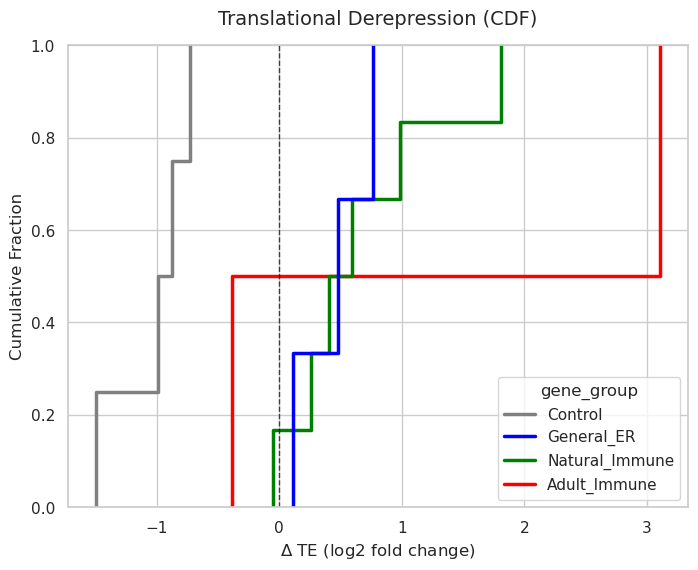

/tmp/ipykernel_8050/596428481.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='gene_group', y='log2_fold_change',


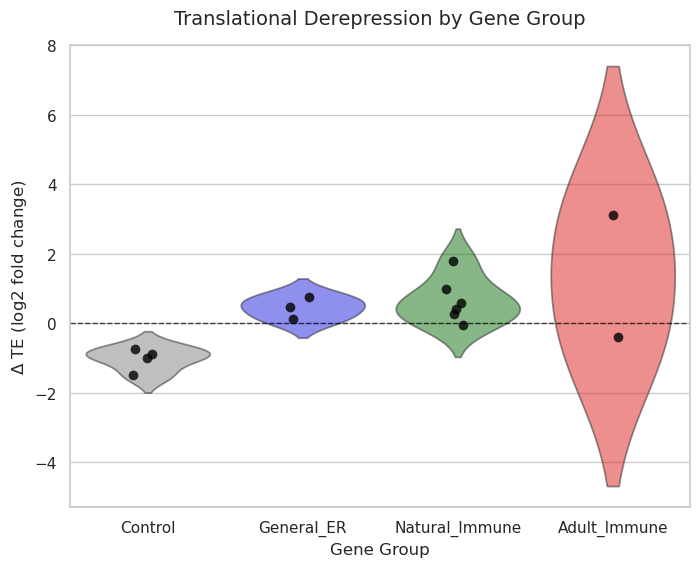

Phase 5 시각화 완료! PNG 파일들이 현재 디렉토리에 저장되었습니다.


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# [Phase 5] High-Quality Visualization (그룹 간 번역 효율 변화 시각화)
# ---------------------------------------------------------

# 타겟 그룹 및 색상 지정 (Plan에 명시된 규칙 적용)
target_groups = ['Control', 'General_ER', 'Natural_Immune', 'Adult_Immune']
color_palette = {
    'Control': 'gray',
    'General_ER': 'blue',
    'Natural_Immune': 'green',
    'Adult_Immune': 'red'
}

# 분석 대상 그룹만 필터링 (log2_fold_change 결측치 제거)
plot_df = df_filtered[df_filtered['gene_group'].isin(target_groups)].dropna(subset=['log2_fold_change'])

# Seaborn 그래프 스타일 설정
sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# 1. 누적 분포 함수 (CDF) Plot
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))
sns.ecdfplot(data=plot_df, x='log2_fold_change', hue='gene_group', 
             hue_order=target_groups, palette=color_palette, linewidth=2.5)

plt.title('Translational Derepression (CDF)', fontsize=14, pad=15)
plt.xlabel('$\Delta$ TE (log2 fold change)', fontsize=12)
plt.ylabel('Cumulative Fraction', fontsize=12)
plt.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)

# 고해상도 저장 및 출력
plt.savefig('translational_derepression_cdf.png', dpi=300, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------
# 2. Violin Plot (밀도 및 중앙값 변화 확인)
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))

# 데이터 수가 적은 것을 고려해 바이올린 플롯 안에 개별 유전자 포인트를 함께 표시
sns.violinplot(data=plot_df, x='gene_group', y='log2_fold_change', 
               order=target_groups, palette=color_palette, inner=None, alpha=0.5)
sns.stripplot(data=plot_df, x='gene_group', y='log2_fold_change', 
              order=target_groups, color='black', size=7, alpha=0.8, jitter=True)

plt.title('Translational Derepression by Gene Group', fontsize=14, pad=15)
plt.xlabel('Gene Group', fontsize=12)
plt.ylabel('$\Delta$ TE (log2 fold change)', fontsize=12)
plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)

# 고해상도 저장 및 출력
plt.savefig('gene_groups_violinplot.png', dpi=300, bbox_inches='tight')
plt.show()

print("Phase 5 시각화 완료! PNG 파일들이 현재 디렉토리에 저장되었습니다.")
